<a href="https://colab.research.google.com/github/Sneha-1503/Healthcare-Predictive-Analytics-Diabetes-Risk-Prediction-Using-Machine-Learning/blob/main/Healthcare_Predictive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

print("Dataset uploaded successfully!")

Saving diabetes_binary_5050split_health_indicators_BRFSS2015.csv to diabetes_binary_5050split_health_indicators_BRFSS2015.csv
Dataset uploaded successfully!


In [5]:

uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("\nUploaded file:", filename)

Saving diabetes_binary_5050split_health_indicators_BRFSS2015.csv to diabetes_binary_5050split_health_indicators_BRFSS2015.csv

Uploaded file: diabetes_binary_5050split_health_indicators_BRFSS2015.csv


In [6]:
df = pd.read_csv(filename)

print("\nDataset loaded successfully!")

print("Original dataset shape:", df.shape)


Dataset loaded successfully!
Original dataset shape: (70692, 22)


In [7]:
print("\nNumber of records:", df.shape[0])
print("Number of features:", df.shape[1] - 1)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())


Number of records: 70692
Number of features: 21

Column names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

First 5 records:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [8]:
TARGET = "Diabetes_binary"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found. "
        f"Available columns are: {df.columns.tolist()}"
    )

print("\nTarget column:", TARGET)

print("\nDiabetes distribution:")
print(df[TARGET].value_counts())

print("\nDiabetes distribution (%):")
print(
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Target column: Diabetes_binary

Diabetes distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

Diabetes distribution (%):
Diabetes_binary
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


In [9]:

missing_values = df.isnull().sum().sum()

print("Total missing values:", missing_values)

if missing_values == 0:
    print("No missing values found.")
else:
    print("Missing values found. Filling numerical columns with median.")

    for column in df.columns:
        if df[column].isnull().sum() > 0:
            df[column] = df[column].fillna(df[column].median())

Total missing values: 0
No missing values found.


In [10]:
duplicates = df.duplicated().sum()

print("\nDuplicate records:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

print("Dataset after duplicate removal:", df.shape)



Duplicate records: 1635
Duplicates removed.
Dataset after duplicate removal: (69057, 22)


In [11]:
X = df.drop(TARGET, axis=1)

y = df[TARGET]

print("\n================ FEATURES / TARGET ================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())



================ FEATURES / TARGET ================
X shape: (69057, 21)
y shape: (69057,)

Feature names:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n TRAIN / TEST")

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


 TRAIN / TEST
Training records: 55245
Testing records: 13812


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nNormalization completed.")


Normalization completed.


In [14]:
logistic_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [15]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [16]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)
print("LOGISTIC REGRESSION RESULTS")
print("Accuracy :", round(lr_accuracy * 100, 2), "%")
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))


LOGISTIC REGRESSION RESULTS
Accuracy : 74.5 %
Precision: 0.738
Recall   : 0.7726
F1 Score : 0.7549
ROC-AUC  : 0.8174


In [17]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=2
)

random_forest.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [18]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]


In [19]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)


In [20]:
print("RANDOM FOREST RESULTS")
print("Accuracy :", round(rf_accuracy * 100, 2), "%")
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))


RANDOM FOREST RESULTS
Accuracy : 74.13 %
Precision: 0.7257
Recall   : 0.7895
F1 Score : 0.7562
ROC-AUC  : 0.8162


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
          ]
})
print("MODEL COMPARISON")
display(
    comparison.round(4)
)



MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7450,0.7380,0.7726,0.7549,0.8174
1,Random Forest,0.7413,0.7257,0.7895,0.7562,0.8162


<Figure size 600x500 with 0 Axes>

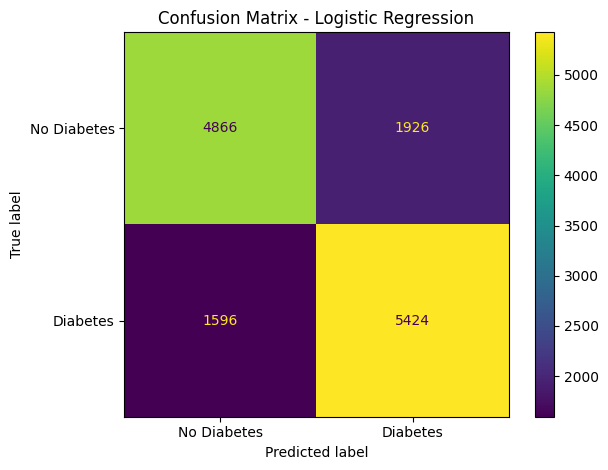

In [23]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.show()


<Figure size 600x500 with 0 Axes>

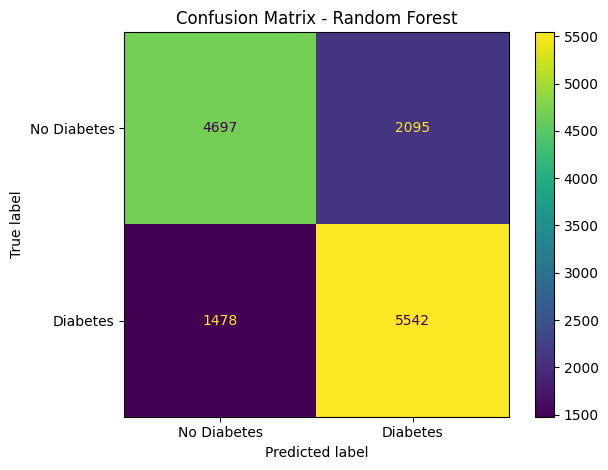

In [24]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

disp.plot()

plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()

plt.show()

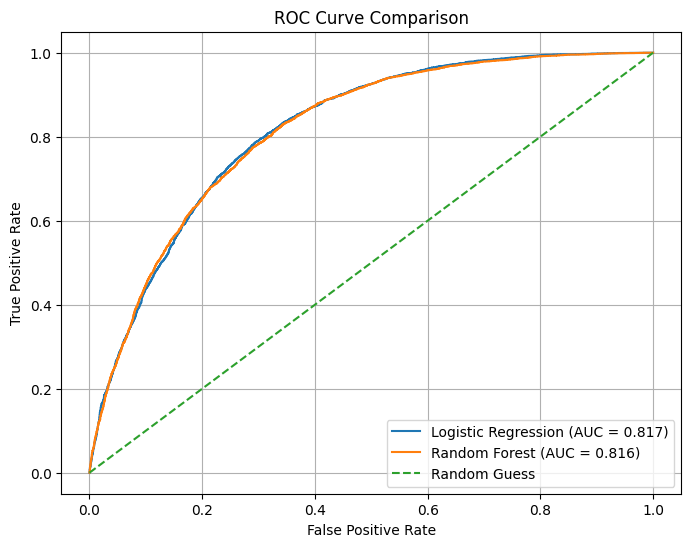

In [25]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid()

plt.show()


In [26]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)
print("TOP 15 RANDOM FOREST FEATURES")

display(
    rf_importance.head(15)
)

TOP 15 RANDOM FOREST FEATURES


,Feature,Importance
3,BMI,0.158273
13,GenHlth,0.138516
18,Age,0.117027
0,HighBP,0.114563
20,Income,0.067779
15,PhysHlth,0.061034
1,HighChol,0.060254
14,MentHlth,0.044345
19,Education,0.042644
16,DiffWalk,0.033762


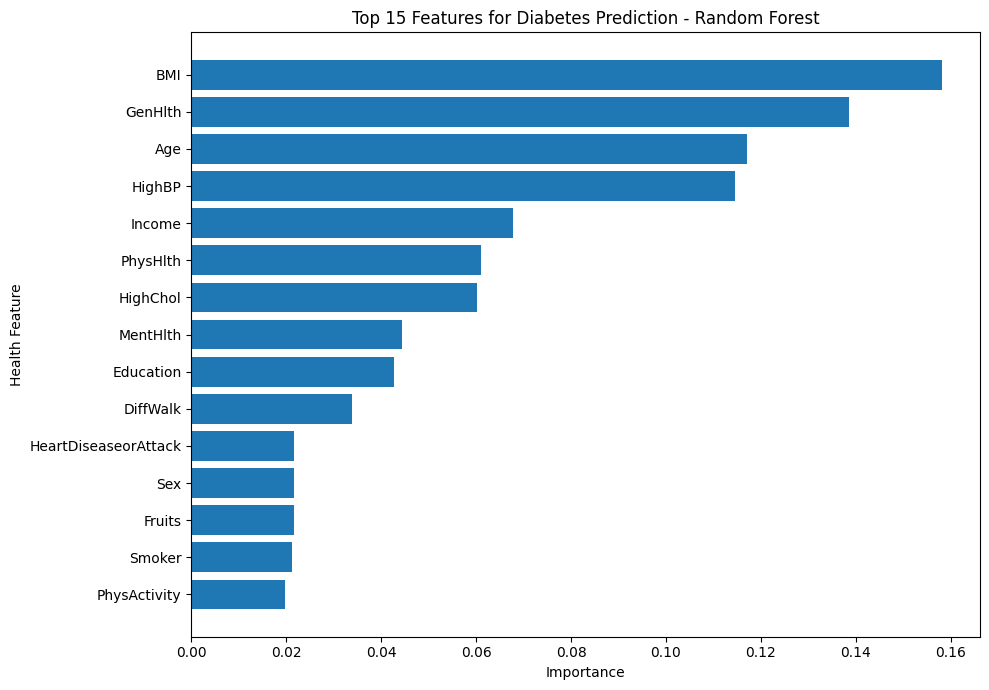

In [27]:
top_rf = rf_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf["Feature"][::-1],
    top_rf["Importance"][::-1]
)

plt.xlabel("Importance")

plt.ylabel("Health Feature")

plt.title(
    "Top 15 Features for Diabetes Prediction - Random Forest"
)

plt.tight_layout()

plt.show()

In [29]:
lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(
        logistic_model.coef_[0]
    )
})

lr_importance = lr_importance.sort_values(
    by="Importance",
    ascending=False
)
print("TOP 15 LOGISTIC REGRESSION FEATURES")
display(
    lr_importance.head(15)
)


TOP 15 LOGISTIC REGRESSION FEATURES


,Feature,Importance
13,GenHlth,0.632240
3,BMI,0.533424
18,Age,0.427834
0,HighBP,0.355615
1,HighChol,0.290534
2,CholCheck,0.219527
10,HvyAlcoholConsump,0.151488
17,Sex,0.129477
20,Income,0.118961
6,HeartDiseaseorAttack,0.095376


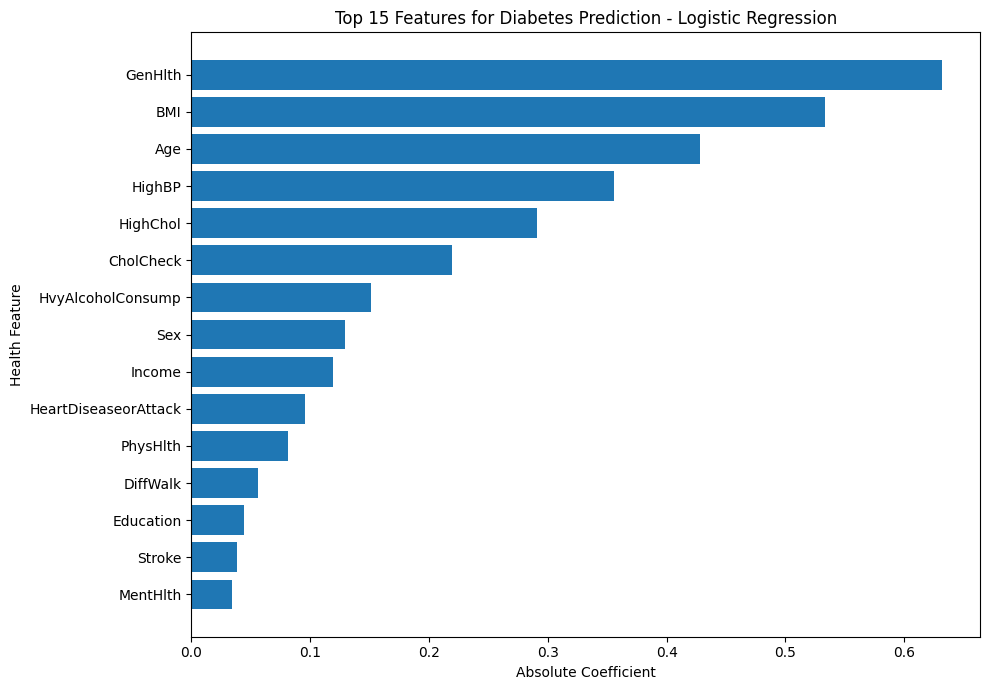

In [30]:
top_lr = lr_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_lr["Feature"][::-1],
    top_lr["Importance"][::-1]
)

plt.xlabel("Absolute Coefficient")

plt.ylabel("Health Feature")

plt.title(
    "Top 15 Features for Diabetes Prediction - Logistic Regression"
)

plt.tight_layout()

plt.show()

In [31]:
if rf_f1 > lr_f1:

    best_model = random_forest
    best_model_name = "Random Forest"
    best_scaler = None

else:

    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_scaler = scaler
print("BEST MODEL")
print("Best model:", best_model_name)

if rf_f1 > lr_f1:
    print("Reason: Higher F1 Score")
else:
    print("Reason: Higher F1 Score")

BEST MODEL
Best model: Random Forest
Reason: Higher F1 Score


In [32]:
joblib.dump(
    best_model,
    "healthcare_diabetes_model.pkl"
)

joblib.dump(
    list(X.columns),
    "healthcare_feature_columns.pkl"
)

if best_scaler is not None:

    joblib.dump(
        best_scaler,
        "healthcare_scaler.pkl"
    )

    print("\nScaler saved.")

else:

    print("\nScaler not required for Random Forest.")


print("\nModel saved successfully!")


Scaler not required for Random Forest.

Model saved successfully!


In [34]:
sample_patient = X_test.iloc[[0]]

actual_value = y_test.iloc[0]
print("SAMPLE PATIENT PREDICTION")

print("Actual diabetes status:", actual_value)


if best_model_name == "Logistic Regression":

    sample_scaled = scaler.transform(
        sample_patient
    )

    prediction = best_model.predict(
        sample_scaled
    )[0]

    probability = best_model.predict_proba(
        sample_scaled
    )[0][1]

else:

    prediction = best_model.predict(
        sample_patient
    )[0]

    probability = best_model.predict_proba(
        sample_patient
    )[0][1]


if prediction == 1:

    result = "Diabetes"

else:

    result = "No Diabetes"


print("Predicted status:", result)

print(
    "Predicted diabetes probability:",
    round(probability * 100, 2),
    "%"
)



SAMPLE PATIENT PREDICTION
Actual diabetes status: 0.0
Predicted status: No Diabetes
Predicted diabetes probability: 28.13 %


In [35]:
performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

performance.to_csv(
    "model_performance.csv",
    index=False
)

rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

lr_importance.to_csv(
    "logistic_regression_feature_importance.csv",
    index=False
)

print("\nPerformance and feature importance files saved.")





Performance and feature importance files saved.


In [36]:

print("DOWNLOADING PROJECT FILES")

files.download(
    "healthcare_diabetes_model.pkl"
)

files.download(
    "healthcare_feature_columns.pkl"
)

if best_scaler is not None:

    files.download(
        "healthcare_scaler.pkl"
    )

files.download(
    "model_performance.csv"
)

files.download(
    "random_forest_feature_importance.csv"
)

files.download(
    "logistic_regression_feature_importance.csv"
)
print("PROJECT COMPLETED!")

print("Best Model:", best_model_name)

print("\nRemember:")
print(
    "This model is for educational/research purposes "
    "and is NOT a medical diagnosis."
)

DOWNLOADING PROJECT FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PROJECT COMPLETED!
Best Model: Random Forest

Remember:
This model is for educational/research purposes and is NOT a medical diagnosis.
